In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
load_dotenv(override=True)

llm = ChatOpenAI()

In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [6]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

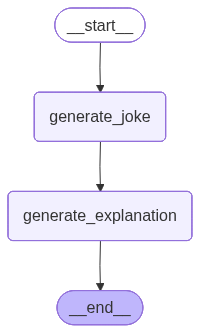

In [9]:
workflow

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the mushroom go to the party? Because he was a fungi and everyone wanted a pizza him!',
 'explanation': 'This joke is making a pun on the word "fungi" which sounds like "fun guy." The joke implies that the mushroom went to the party because he was a fun person to be around and everyone wanted to hang out with him. The second part of the joke plays on the fact that mushrooms are a common pizza topping, so everyone wanted a "piece of him" at the party. It\'s a light-hearted and silly joke that plays on wordplay and common cultural references.'}

In [11]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the mushroom go to the party? Because he was a fungi and everyone wanted a pizza him!', 'explanation': 'This joke is making a pun on the word "fungi" which sounds like "fun guy." The joke implies that the mushroom went to the party because he was a fun person to be around and everyone wanted to hang out with him. The second part of the joke plays on the fact that mushrooms are a common pizza topping, so everyone wanted a "piece of him" at the party. It\'s a light-hearted and silly joke that plays on wordplay and common cultural references.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1670cf-7728-65d3-8002-b03bf4d8ac32'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T09:48:01.394111+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1670cf-649a-6dae-8001-8f50bf69f681'}}, tasks=(), interrupts=())

In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the mushroom go to the party? Because he was a fungi and everyone wanted a pizza him!', 'explanation': 'This joke is making a pun on the word "fungi" which sounds like "fun guy." The joke implies that the mushroom went to the party because he was a fun person to be around and everyone wanted to hang out with him. The second part of the joke plays on the fact that mushrooms are a common pizza topping, so everyone wanted a "piece of him" at the party. It\'s a light-hearted and silly joke that plays on wordplay and common cultural references.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1670cf-7728-65d3-8002-b03bf4d8ac32'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T09:48:01.394111+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1670cf-649a-6dae-8001-8f50bf69f681'}}, tasks=(), interrupts=()),
 St

In [13]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta go to the party? Because it heard it was going to be a pasta-tively fun time!',
 'explanation': 'This joke plays on the word play between "pasta" and "positively". The pasta went to the party because it heard it was going to be a "pasta-tively" fun time, using a pun on the word "positively". This joke is humorous because it combines a common food item (pasta) with a pun to create a light-hearted and silly punchline.'}

In [16]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the party? Because it heard it was going to be a pasta-tively fun time!', 'explanation': 'This joke plays on the word play between "pasta" and "positively". The pasta went to the party because it heard it was going to be a "pasta-tively" fun time, using a pun on the word "positively". This joke is humorous because it combines a common food item (pasta) with a pun to create a light-hearted and silly punchline.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1670dd-f97c-67da-8002-923bd5aaed1f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T09:54:30.869756+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1670dd-e84b-6672-8001-c09857d777a3'}}, tasks=(), interrupts=())

In [20]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the party? Because it heard it was going to be a pasta-tively fun time!', 'explanation': 'This joke plays on the word play between "pasta" and "positively". The pasta went to the party because it heard it was going to be a "pasta-tively" fun time, using a pun on the word "positively". This joke is humorous because it combines a common food item (pasta) with a pun to create a light-hearted and silly punchline.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1670dd-f97c-67da-8002-923bd5aaed1f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T09:54:30.869756+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1670dd-e84b-6672-8001-c09857d777a3'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the party? Because it heard it was going to be

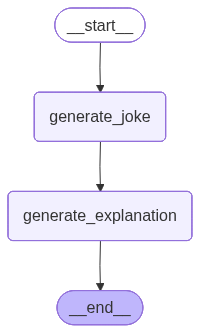

In [19]:
workflow

### Time Travel

In [23]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the mushroom go to the party? Because he was a fungi and everyone wanted a pizza him!', 'explanation': 'This joke is making a pun on the word "fungi" which sounds like "fun guy." The joke implies that the mushroom went to the party because he was a fun person to be around and everyone wanted to hang out with him. The second part of the joke plays on the fact that mushrooms are a common pizza topping, so everyone wanted a "piece of him" at the party. It\'s a light-hearted and silly joke that plays on wordplay and common cultural references.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1670cf-7728-65d3-8002-b03bf4d8ac32'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T09:48:01.394111+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1670cf-649a-6dae-8001-8f50bf69f681'}}, tasks=(), interrupts=()),
 St

In [24]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": '1f1670cf-52cd-618a-8000-2f8517b006d6'}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1670cf-52cd-618a-8000-2f8517b006d6'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-13T09:47:57.581943+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1670cf-52ca-66c1-bfff-b60b56a226a8'}}, tasks=(PregelTask(id='c7e2766c-df6c-b18d-ee66-e7d60ecc5b65', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the mushroom go to the party? Because he was a fungi and everyone wanted a pizza him!'}),), interrupts=())

In [25]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": '1f1670cf-52cd-618a-8000-2f8517b006d6'}})

{'topic': 'pizza',
 'joke': "Why did the pizza maker break up with their oven? They just couldn't handle the heat anymore.",
 'explanation': 'This joke plays on the expression "if you can\'t handle the heat, get out of the kitchen", which means if you can\'t handle pressure or difficult situations, then you should remove yourself from that environment. In this case, the pizza maker and the oven are in a kitchen setting where it can get very hot while making pizzas. The joke implies that the pizza maker broke up with the oven because the oven couldn\'t handle the heat, meaning it couldn\'t handle the high temperatures required for baking pizzas. So, they had to part ways because the oven couldn\'t handle the heat, both literally and figuratively.'}

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza maker break up with their oven? They just couldn't handle the heat anymore.", 'explanation': 'This joke plays on the expression "if you can\'t handle the heat, get out of the kitchen", which means if you can\'t handle pressure or difficult situations, then you should remove yourself from that environment. In this case, the pizza maker and the oven are in a kitchen setting where it can get very hot while making pizzas. The joke implies that the pizza maker broke up with the oven because the oven couldn\'t handle the heat, meaning it couldn\'t handle the high temperatures required for baking pizzas. So, they had to part ways because the oven couldn\'t handle the heat, both literally and figuratively.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f167119-d6cf-6d11-8002-5d3c6598dc5c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T10:21:17.84

#### Updating State

In [27]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f167125-f7b4-60f8-8000-02a759548cf1'}}

In [28]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f167125-f7b4-60f8-8000-02a759548cf1'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-13T10:26:43.418126+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='b26de59c-e00f-b126-9d9e-661886c64504', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza maker break up with their oven? They just couldn't handle the heat anymore.", 'explanation': 'This joke plays on the expression "if you can\'t handle the heat, get out of the kitchen", which means if you can\'t handle pressure or difficult situations, then you should remove yourself from that environment. In th

In [29]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": '1f167125-f7b4-60f8-8000-02a759548cf1'}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to the party? Because it wanted to mix and mingle with the other snacks!',
 'explanation': 'This joke plays on the double meaning of the phrase "mix and mingle." In a social context, "mix and mingle" usually means to interact and socialize with others at a party or gathering. In this joke, the samosa\'s desire to "mix and mingle" is interpreted as wanting to physically mix with the other snacks at the party. This creates a humorous image of the samosa literally wanting to blend in with the other food items, leading to a playful and light-hearted punchline.'}

In [30]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to the party? Because it wanted to mix and mingle with the other snacks!', 'explanation': 'This joke plays on the double meaning of the phrase "mix and mingle." In a social context, "mix and mingle" usually means to interact and socialize with others at a party or gathering. In this joke, the samosa\'s desire to "mix and mingle" is interpreted as wanting to physically mix with the other snacks at the party. This creates a humorous image of the samosa literally wanting to blend in with the other food items, leading to a playful and light-hearted punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16712b-23e4-6d1e-8002-f7058ce558ce'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T10:29:02.269548+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16712b-1658-648f-8001-e0f44c1e05d9'}}

### Fault Tolerance

In [31]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [32]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [40]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [41]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [42]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [43]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [44]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f167137-cf07-6df7-8003-17a0ee68a2a3'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-06-13T10:34:42.337117+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f167137-cf05-6a22-8002-75daa4d6306b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f167137-cf05-6a22-8002-75daa4d6306b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-13T10:34:42.336191+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f167137-3563-67d4-8001-df61a79a4745'}}, tasks=(PregelTask(id='69d41ddd-ab77-9310-7057-fb41a6b4fb2